Q9 — Architecture du modèle
Le sujet suggère de partir d'un CNN simple comme baseline. C'est la bonne approche pour un hackathon : d'abord quelque chose qui marche, ensuite on améliore.

In [8]:
import torch
import torch.nn as nn

class RespiratoryCNN(nn.Module):
    def __init__(self, num_classes=5, in_channels=6):
        super().__init__()

        # Bloc 1 — détecte les patterns simples (bords, textures)
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),      # 128×259 → 64×129
            nn.Dropout2d(0.25)
        )

        # Bloc 2 — détecte les patterns plus complexes
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),      # 64×129 → 32×64
            nn.Dropout2d(0.25)
        )

        # Bloc 3 — patterns de haut niveau
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),  # → 128×4×4 = 2048 features
            nn.Dropout2d(0.25)
        )

        # Classifieur final
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

# Vérifier les dimensions (6 canaux : mel, mfcc, centroid, bandwidth, zcr, chroma)
model = RespiratoryCNN(num_classes=5, in_channels=6)
dummy = torch.randn(8, 6, 128, 259)   # batch=8, canaux=6, H=128, W=259
out = model(dummy)
print(f"Sortie : {out.shape}")

Sortie : torch.Size([8, 5])


Pour la présentation, justifie le choix CNN ainsi : les Mel-spectrogrammes sont des images 2D — les CNN sont conçus exactement pour ça, ils apprennent des filtres locaux (comme détecter une bande horizontale de wheezing) sans qu'on ait à les programmer manuellement.


Q10 — Split stratifié 70/15/15
Le split stratifié garantit que chaque classe (y compris Bronchial qui est rare) est représentée proportionnellement dans chaque split.

In [9]:
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.preprocessing import LabelEncoder

# Chargement des données depuis le fichier unifié
spectres = np.load("spectres.npy", allow_pickle=True).item()
mels = spectres["mel"]
labels = spectres["labels"]

assert len(mels) == len(labels), "Désalignement entre mels et labels dans spectres.npy"
print(f"Mels: {mels.shape} | Labels: {labels.shape}")

# Encodage des labels en entiers
le = LabelEncoder()
y_enc = le.fit_transform(labels)  # ex: asthma->0, bronchial->1...
print("Classes :", le.classes_)

# Split stratifié en 3 parties
indices = np.arange(len(mels))

# D'abord : 70% train / 30% temp
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(sss1.split(indices, y_enc))

# Ensuite : 30% temp -> 15% val / 15% test
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx, test_idx = next(sss2.split(temp_idx, y_enc[temp_idx]))
val_idx = temp_idx[val_idx]
test_idx = temp_idx[test_idx]

print(f"Train : {len(train_idx)} | Val : {len(val_idx)} | Test : {len(test_idx)}")

# Vérifier la distribution dans chaque split
for name, idx in [("Train", train_idx), ("Val", val_idx), ("Test", test_idx)]:
    split_labels = y_enc[idx]
    unique, counts = np.unique(split_labels, return_counts=True)

    print(f"\n{name} :")
    for cls_id, cnt in zip(unique, counts):
        cls_name = le.classes_[cls_id]
        print(f"  {cls_name:12s} : {cnt:3d} ({cnt/len(idx)*100:.1f}%)")

Mels: (1211, 128, 259) | Labels: (1211,)
Classes : ['Bronchial' 'asthma' 'copd' 'healthy' 'pneumonia']
Train : 847 | Val : 182 | Test : 182

Train :
  Bronchial    :  73 (8.6%)
  asthma       : 201 (23.7%)
  copd         : 281 (33.2%)
  healthy      :  93 (11.0%)
  pneumonia    : 199 (23.5%)

Val :
  Bronchial    :  15 (8.2%)
  asthma       :  44 (24.2%)
  copd         :  60 (33.0%)
  healthy      :  20 (11.0%)
  pneumonia    :  43 (23.6%)

Test :
  Bronchial    :  16 (8.8%)
  asthma       :  43 (23.6%)
  copd         :  60 (33.0%)
  healthy      :  20 (11.0%)
  pneumonia    :  43 (23.6%)


In [10]:
import torch
import torch.nn.functional as F

class MultiSpectreDataset(Dataset):
    def __init__(self, spectres, labels, feature_keys=None):
        self.spectres = spectres
        self.y = torch.LongTensor(labels)
        self.feature_keys = feature_keys or ["mel", "mfcc", "centroid", "bandwidth", "zcr", "chroma"]
        self.num_channels = len(self.feature_keys)

    def __len__(self):
        return len(self.y)

    @staticmethod
    def _to_2d(arr):
        arr = np.asarray(arr, dtype=np.float32)
        if arr.ndim == 1:
            return arr[np.newaxis, :]
        return arr

    @staticmethod
    def _resize_2d(arr_2d, target_h, target_w):
        x = torch.tensor(arr_2d, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # (1,1,H,W)
        x = F.interpolate(x, size=(target_h, target_w), mode="bilinear", align_corners=False)
        return x.squeeze(0).squeeze(0).numpy()

    def __getitem__(self, idx):
        mel = self._to_2d(self.spectres["mel"][idx])
        target_h, target_w = mel.shape

        channels = []
        for key in self.feature_keys:
            feat = self._to_2d(self.spectres[key][idx])
            if feat.shape != (target_h, target_w):
                feat = self._resize_2d(feat, target_h, target_w)
            channels.append(feat)

        x = np.stack(channels, axis=0).astype(np.float32)  # (C, H, W)
        return torch.from_numpy(x), self.y[idx]

full_dataset = MultiSpectreDataset(spectres, y_enc)
print(f"Canaux utilisés : {full_dataset.feature_keys}")
print(f"Nombre de canaux : {full_dataset.num_channels}")

train_loader = DataLoader(Subset(full_dataset, train_idx), batch_size=32, shuffle=True)
val_loader   = DataLoader(Subset(full_dataset, val_idx), batch_size=32, shuffle=False)
test_loader  = DataLoader(Subset(full_dataset, test_idx), batch_size=32, shuffle=False)

Canaux utilisés : ['mel', 'mfcc', 'centroid', 'bandwidth', 'zcr', 'chroma']
Nombre de canaux : 6


Boucle d'entraînement avec class weights

In [11]:
from sklearn.utils.class_weight import compute_class_weight

# Calcul des poids pour compenser le déséquilibre (Q2)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_enc),
    y=y_enc[train_idx]        # calculé sur le train seulement
)
weights_tensor = torch.FloatTensor(class_weights)

model = RespiratoryCNN(
    num_classes=len(le.classes_),
    in_channels=full_dataset.num_channels
)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5
)

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct = 0, 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        out = model(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (out.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            out = model(X_batch)
            loss = criterion(out, y_batch)
            total_loss += loss.item()
            correct += (out.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

# Entraînement
EPOCHS = 50
for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion)
    scheduler.step(val_loss)

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch+1:3d} | "
            f"Train loss {train_loss:.3f} acc {train_acc:.3f} | "
            f"Val loss {val_loss:.3f} acc {val_acc:.3f}"
        )

# Sauvegarder le modèle
torch.save(model.state_dict(), "cnn_respiratory.pth")

Epoch   5 | Train loss 1.266 acc 0.510 | Val loss 1.099 acc 0.571
Epoch  10 | Train loss 1.174 acc 0.541 | Val loss 1.031 acc 0.593
Epoch  15 | Train loss 1.083 acc 0.584 | Val loss 0.929 acc 0.632
Epoch  20 | Train loss 0.996 acc 0.621 | Val loss 0.846 acc 0.648
Epoch  25 | Train loss 0.957 acc 0.623 | Val loss 0.877 acc 0.615
Epoch  30 | Train loss 0.949 acc 0.615 | Val loss 0.789 acc 0.659
Epoch  35 | Train loss 0.888 acc 0.639 | Val loss 0.745 acc 0.670
Epoch  40 | Train loss 0.879 acc 0.658 | Val loss 0.718 acc 0.709
Epoch  45 | Train loss 0.850 acc 0.669 | Val loss 0.707 acc 0.725
Epoch  50 | Train loss 0.839 acc 0.682 | Val loss 0.682 acc 0.731


Q11 — Métriques adaptées au contexte médical
L'accuracy seule ne suffit pas — un modèle qui prédit toujours "COPD" (classe majoritaire) aurait ~30% d'accuracy sans rien apprendre.

              precision    recall  f1-score   support

   Bronchial       0.56      0.31      0.40        16
      asthma       0.82      0.95      0.88        43
        copd       0.80      0.65      0.72        60
     healthy       0.61      1.00      0.75        20
   pneumonia       0.76      0.72      0.74        43

    accuracy                           0.75       182
   macro avg       0.71      0.73      0.70       182
weighted avg       0.75      0.75      0.74       182

Macro F1-score : 0.698
Macro AUC-ROC  : 0.950


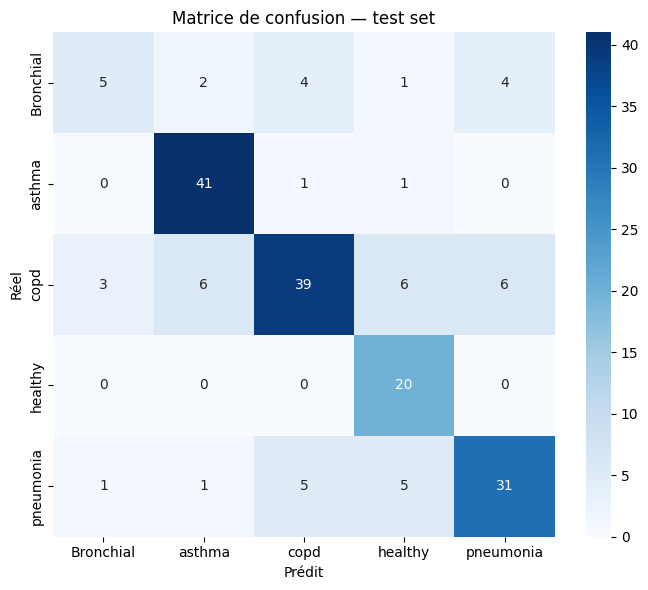

In [12]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, f1_score)
import matplotlib.pyplot as plt
import seaborn as sns

model.eval()
all_preds, all_probs, all_true = [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        out   = model(X_batch)
        probs = torch.softmax(out, dim=1)
        all_preds.extend(out.argmax(1).numpy())
        all_probs.extend(probs.numpy())
        all_true.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
all_true  = np.array(all_true)

# Rapport complet
print(classification_report(all_true, all_preds,
                              target_names=le.classes_))

# Macro F1 — pondère également chaque classe
f1_macro = f1_score(all_true, all_preds, average='macro')
print(f"Macro F1-score : {f1_macro:.3f}")

# AUC-ROC multiclasse
auc = roc_auc_score(all_true, all_probs, multi_class='ovr', average='macro')
print(f"Macro AUC-ROC  : {auc:.3f}")

# Matrice de confusion
cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Matrice de confusion — test set")
plt.ylabel("Réel")
plt.xlabel("Prédit")
plt.tight_layout()
plt.show()

Pour la présentation, insiste sur ce point clé : en médecine, un faux négatif (manquer une pneumonie) est bien plus grave qu'un faux positif. C'est pourquoi on surveille le recall par classe en priorité sur l'accuracy globale.

Q12 — Data augmentation avec SpecAugment
SpecAugment s'applique directement sur les Mel-spectrogrammes pendant l'entraînement — pas besoin de régénérer les fichiers.

In [13]:
import torch
import random

def spec_augment(mel, freq_mask_param=20, time_mask_param=40, num_masks=2):
    """
    Applique SpecAugment sur un tensor Mel (H, W)
    freq_mask_param : largeur max du masque fréquentiel (en bandes Mel)
    time_mask_param : largeur max du masque temporel (en frames)
    num_masks       : nombre de masques appliqués par axe
    """
    mel = mel.clone()
    H, W = mel.shape

    # Masques fréquentiels — cache des bandes horizontales
    for _ in range(num_masks):
        f = random.randint(0, freq_mask_param)
        f0 = random.randint(0, max(0, H - f))
        mel[f0:f0 + f, :] = 0.0

    # Masques temporels — cache des bandes verticales
    for _ in range(num_masks):
        t = random.randint(0, time_mask_param)
        t0 = random.randint(0, max(0, W - t))
        mel[:, t0:t0 + t] = 0.0

    return mel

# Dataset multi-spectres avec augmentation appliquée sur le canal Mel (canal 0)
class MultiSpectreDatasetAug(MultiSpectreDataset):
    def __init__(self, spectres, labels, feature_keys=None, augment=False):
        super().__init__(spectres, labels, feature_keys=feature_keys)
        self.augment = augment

    def __getitem__(self, idx):
        x, y = super().__getitem__(idx)
        if self.augment:
            x = x.clone()
            x[0] = spec_augment(x[0])
        return x, y

# Remplacer le train_loader par la version augmentée
feature_keys = full_dataset.feature_keys
train_spectres = {k: np.asarray(v)[train_idx] for k, v in spectres.items() if k != "labels"}
train_dataset_aug = MultiSpectreDatasetAug(
    train_spectres,
    y_enc[train_idx],
    feature_keys=feature_keys,
    augment=True
)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=32, shuffle=True)

print(f"Train loader augmenté prêt avec {train_dataset_aug.num_channels} canaux")

Train loader augmenté prêt avec 6 canaux
